In [ ]:
import pandas as pd
from pathlib import Path
df = pd.read_csv("D:\\Business Analyst\\Python\\ml_assesment\\Data\\q1_heart_disease.csv")#loading data
print("Shape of dataset:", df.shape)#dataset shape
print("Data Types:\n", df.dtypes)# data type
print("Null values count:\n", df.isnull().sum())#null value identification
print("Rows:\n", df.head())#printing rows

Shape of dataset: (800, 12)
Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
Null values count:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64
Rows:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0 

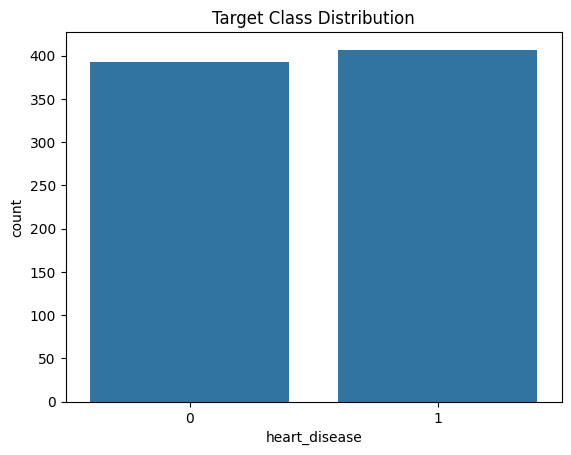

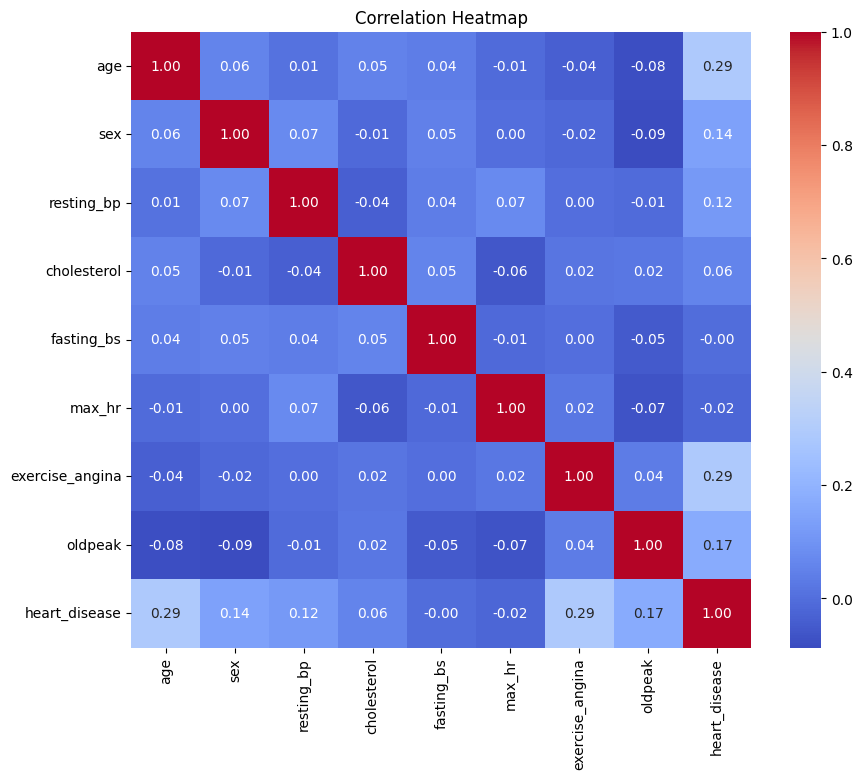

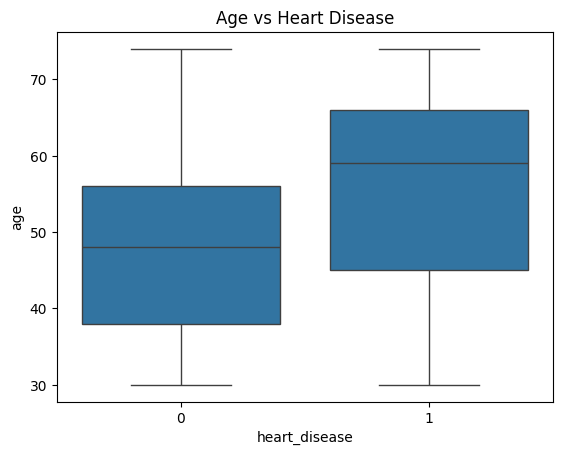

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# distribution plot 
sns.countplot(x='heart_disease', data=df)
plt.title("Target Class Distribution")
plt.show()

# heatmap
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#Example with column with boxplot
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# missing values handling 
df = df.fillna(df.median(numeric_only=True))
# categorical columns
categorical_cols = [
    'sex', 'chest_pain_type', 'fasting_bs',
    'resting_ecg', 'exercise_angina', 'st_slope'
]
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Split features & target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# model initialization
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Output of model training
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Evaluate all models
evaluate_model(dt, "Decision Tree")
evaluate_model(rf, "Random Forest")
evaluate_model(gb, "Gradient Boosting")


Decision Tree
Confusion Matrix:
 [[59 20]
 [24 57]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73        79
           1       0.74      0.70      0.72        81

    accuracy                           0.72       160
   macro avg       0.73      0.73      0.72       160
weighted avg       0.73      0.72      0.72       160


Random Forest
Confusion Matrix:
 [[58 21]
 [16 65]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
  